<a href="https://colab.research.google.com/github/Nawaf-Alorabi/Tw_Customer_Churn_Prediction_System_DeepLearn/blob/main/Nawaf_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import seaborn as sns
sns.set(style="whitegrid")
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

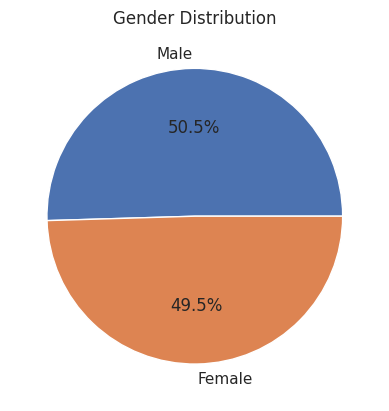

In [11]:
df['gender'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

Insight: Compare churn rates between male and female customers

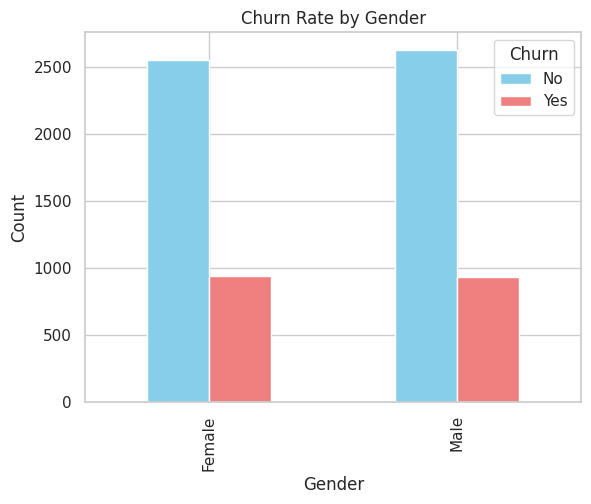

In [13]:
# حساب القيم
data = df.groupby(['gender', 'Churn']).size().unstack()

# رسم الأعمدة
data.plot(kind='bar', color=['skyblue', 'lightcoral'])

plt.title('Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

Insight: Understand how long customers typically stay with the company.



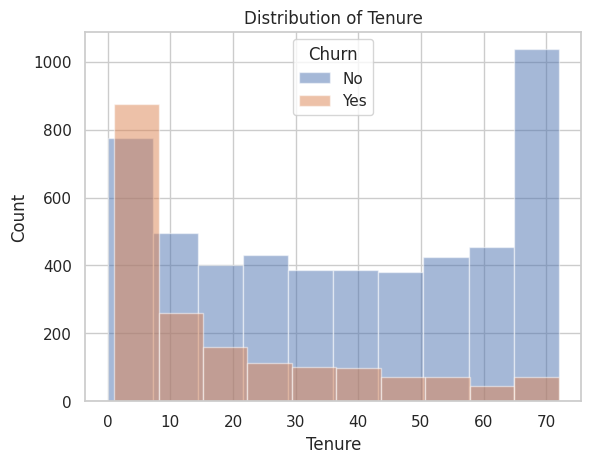

In [16]:
for churn_value in df['Churn'].unique():
    plt.hist(df[df['Churn'] == churn_value]['tenure'], alpha=0.5, label=churn_value)

plt.title('Distribution of Tenure')
plt.xlabel('Tenure')
plt.ylabel('Count')
plt.legend(title='Churn')
plt.show()

Insight: Analyze how phone service affects churn

In [17]:
df.drop("customerID",axis='columns',inplace=True)

# Data Preprocessing


In [18]:
def object_to_int(data):
    if data.dtype=='object':
        data = LabelEncoder().fit_transform(data)
    return data

In [19]:
df = df.apply(lambda x: object_to_int(x))
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,2505,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157,1


In [20]:
plt.figure(figsize=(14,7))
df.corr()['Churn'].sort_values(ascending = False)

,Churn
Churn,1.000000
MonthlyCharges,0.193356
PaperlessBilling,0.191825
SeniorCitizen,0.150889
PaymentMethod,0.107062
MultipleLines,0.038037
TotalCharges,0.014479
PhoneService,0.011942
gender,-0.008612
StreamingTV,-0.036581


<Figure size 1400x700 with 0 Axes>

In [21]:
X = df.drop('Churn', axis= 1)
y = df['Churn']

In [23]:
# MinMaxScaler is very useful when the data is unbalanced.
# Algorithms like Neural Networks and KNN benefit from it.

mn = MinMaxScaler()
X = mn.fit_transform(X)

In [24]:
# MinMaxScaler is very useful when the data is unbalanced.

mn = MinMaxScaler()
X = mn.fit_transform(X)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, stratify= y, random_state= 42)


SMOTE generates synthetic samples for the minority class to balance the dataset, improving model performance, especially for imbalanced classification problems.

In [26]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='minority')
X_sm, y_sm = smote.fit_resample(X_train, y_train)

In [27]:
print(y_sm.value_counts())
print(y_test.value_counts())

Churn
0    4139
1    4139
Name: count, dtype: int64
Churn
0    1035
1     374
Name: count, dtype: int64


In [28]:
X_train.shape

(5634, 19)

In [29]:
model = keras.models.Sequential([
    keras.layers.Dense(19,input_shape=(19,),activation='relu'),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(1,activation='sigmoid')
])

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

model.fit(X_sm, y_sm,
                 batch_size=8,
                 epochs=10,
                 verbose=1)

Epoch 1/10
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7509 - loss: 0.5102
Epoch 2/10
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7737 - loss: 0.4742
Epoch 3/10
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7777 - loss: 0.4667
Epoch 4/10
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7811 - loss: 0.4602
Epoch 5/10
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7842 - loss: 0.4533
Epoch 6/10
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7879 - loss: 0.4504
Epoch 7/10
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7932 - loss: 0.4438
Epoch 8/10
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7963 - loss: 0.4392
Epoch 9/10
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8008 - loss: 0.4356
Epoch 10/10
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8000 - loss: 0.4329


In [30]:
test_acc = model.evaluate(X_test, y_test)
print('Loss value is ',test_acc[0])
print('Accuracy value is ',test_acc[1])

45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7438 - loss: 0.4888
Loss value is  0.48877647519111633
Accuracy value is  0.7437899112701416


In [31]:
yp=model.predict(X_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


In [32]:
y_pred = []

for element in yp:
    if element > 0.5:
        y_pred.append(1)
    else:
        y_pred.append(0)

In [33]:
from sklearn import metrics

# Calculate metrics
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
f1 = metrics.f1_score(y_test, y_pred)
auc = metrics.roc_auc_score(y_test, yp)
# Print metrics
print("Neural Network Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC: {auc:.4f}")
print('\nClassification Report:\n', metrics.classification_report(y_test, y_pred))

Neural Network Metrics:
Accuracy: 0.7438
Precision: 0.5130
Recall: 0.6872
F1-score: 0.5874
AUC: 0.8186

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.76      0.81      1035
           1       0.51      0.69      0.59       374

    accuracy                           0.74      1409
   macro avg       0.69      0.73      0.70      1409
weighted avg       0.78      0.74      0.75      1409



In [34]:
conf_matrix = metrics.confusion_matrix(y_test, y_pred)
conf_mat_df = pd.DataFrame(
    conf_matrix,
    columns=["Predicted Negative", "Predicted Positive"],
    index=["Actual Negative", "Actual Positive"]
)
print('\nConfusion Matrix:')
conf_mat_df


Confusion Matrix:


,Predicted Negative,Predicted Positive
Actual Negative,791,244
Actual Positive,117,257
